In [1]:
import torch
import lightning
import copy
from mlcolvar.cvs import BaseCV
from mlcolvar.core import FeedForward
import numpy as np
from mlcolvar.data import DictDataset
from mlcolvar.cvs.committor.utils import compute_committor_weights
from mlcolvar.cvs.generator import Generator
import MDAnalysis as mda
from mlcolvar.cvs.committor.utils import compute_committor_weights
from mlcolvar.core.transform.descriptors import ReducedFFEnergy
from mlcolvar.core.transform.tools import LogHistogram
from mlcolvar.core.loss.utils.smart_derivatives import compute_descriptors_derivatives
from mlcolvar.cvs.indicator import IndicatorTraining, IndicatorProduction, IndicatorBiasModel
from mlcolvar.data import DictModule
from mlcolvar.utils.trainer import MetricsCallback
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import matplotlib.pyplot as plt
from mlcolvar.utils.plot import plot_metrics

torch.set_default_dtype(torch.float64)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/fdietrich@iit.local/miniconda3/envs/ensemblecolvar/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Prepare Settings and Load Data

In [2]:
cell = torch.Tensor([3.0233, 3.0233, 3.0233]).to(device)
print('Cell: ', cell)
# temperature in Kelvin
T = 300 
# Boltzmann factor in the RIGHT ENRGY UNITS!
kb = 0.0083144621
beta = 1/(kb*T)
kT = 1/beta
print(f'Beta: {beta} \n1/beta: {1/beta}')

Cell:  tensor([3.0233, 3.0233, 3.0233], device='cuda:0')
Beta: 0.4009078751268027 
1/beta: 2.4943386299999997


In [ ]:
# Define your energy function
n_at = 22
energy = ReducedFFEnergy.from_files(
    n_atoms=n_at,
    bonds_file="../sim_template/bonds_mm.dat", # Path to the input files for the equivalent Plumed function
    angles_file="../sim_template/angles_mm.dat", # Files contain info on which atoms are 1-2,1-3 and 1-4 neighbours
    dihedrals_file="../sim_template/dihedrals_mm.dat",
    lj_peratom_file="../sim_template/lj_peratom_mm.dat", # Contains true LJ parameters for each atom
    use_lj=True,
    lj_cutoff=1.2, # Match the cutoff to the gromacs input
    lj_comb="LB", # Lennard-Jones combination rule: LB = Lorentz-Berthelot
    use_coulomb=True,
    charges_file="../sim_template/charges_mm.dat", # Contains true charges for each atom
    epsilon_r=1, # Relative permittivity (dielectric constant) for Coulomb interactions, can be set to implicitly include solvent effects 
    exclude12=True, # Exclude close neighbour interactions to filter out thermal noise
    exclude13=True,
    scale14=0,
    box = cell,
    n_replicas=1,
)

In [18]:
u_unbiased = mda.Universe("../test_data/ala.gro", "../test_data/traj_comp.xtc")

e_unbound = []

for t in u_unbiased.trajectory:
    ats = u_unbiased.atoms.select_atoms("all")
    pos = ats.atoms.positions / 10.0
    pos_tensor = torch.tensor(pos.flatten(), dtype=torch.get_default_dtype()).view(1, -1)
    e = energy(pos_tensor)
    e_unbound.append(float(e.item()))

(array([0.        , 0.00015748, 0.00313844, 0.02743601, 0.04811144,
        0.02932582, 0.00418458, 0.00014624, 0.        ]),
 array([-380.        , -371.11111111, -362.22222222, -353.33333333,
        -344.44444444, -335.55555556, -326.66666667, -317.77777778,
        -308.88888889, -300.        ]),
 <BarContainer object of 9 artists>)

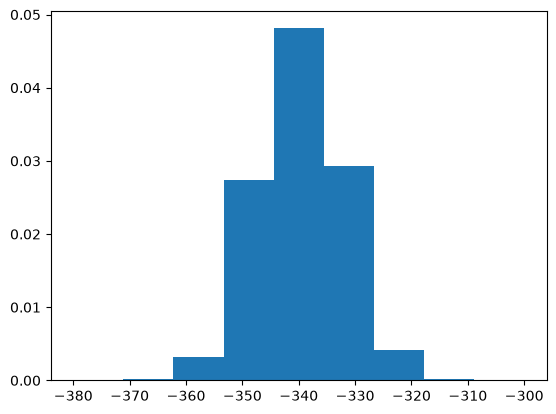

In [15]:
# Estimate the histogram range, leaving room potential higher or lower energy states
# Keep the resolution just large enough to distinguish the distribution tails from the bulk of the distribution 
bins = np.linspace(-380, -300, 10)
plt.hist(e_unbound, bins=bins, density=True)

In [20]:
n_rep = 20
pos_unbiased = []
for t in u_unbiased.trajectory:
    ats = u_unbiased.atoms.select_atoms("all")
    pos = ats.atoms.positions / 10.0
    pos_tensor = torch.tensor(pos.flatten(), dtype=torch.get_default_dtype()).view(1, -1)
    pos_unbiased.append(pos_tensor)

pos_unbiased = torch.cat(pos_unbiased)
labels_unbiased = torch.ones(pos_unbiased.shape[0])
pos_all = torch.cat([pos_unbiased])
labels_all = torch.cat([labels_unbiased])

ds_unbiased = DictDataset({"data": pos_all[::10], "labels": labels_all[::10]})
# Create synthetic data for 20 unbiased replicas
new_data = torch.zeros(1001, n_at*3*n_rep)

for i in range(n_rep):
    new_data[:,n_at*3*i:n_at*3*i+n_at*3] = pos_unbiased[torch.randperm(pos_unbiased.size()[0])[::10]]

ds_unbiased["data"] = new_data

In [ ]:
# compute weights
ds = compute_committor_weights(dataset=ds_unbiased,
                                    bias=torch.zeros(len(pos_all[::10])),
                                    data_groups=[0],
                                    beta=beta)


# Identify indices of heavy atoms for biasing
ats = u_unbiased.atoms.select_atoms("all")
heavy = ats.select_atoms("not name H*")
heavy_indices = heavy.indices

# Step 2: Define the Descriptor and Preprocessing Layer
- Plot average energy distributions for your known state
- Define a reasonable range for the histogram leaving room for lower and/or higher energy states
- This choice is not critical and can be modified in following iterations in case states are encountered that fall outside of the range

In [27]:
# Descriptors
mm_energy = ReducedFFEnergy.from_files(
    n_atoms=n_at,
    bonds_file="../sim_template/bonds_mm.dat",
    angles_file="../sim_template/angles_mm.dat",
    dihedrals_file="../sim_template/dihedrals_mm.dat",
    lj_peratom_file="../sim_template/lj_peratom_mm.dat",
    use_lj=True,
    lj_cutoff=1.2,
    lj_comb="LB",
    use_coulomb=True,
    charges_file="../sim_template/charges_mm.dat",
    epsilon_r=1,
    exclude12=True,
    exclude13=True,
    scale14=0,
    box = cell,
    #force_atoms = heavy_indices,
    n_replicas=n_rep
)

hist_ene = LogHistogram(in_features=20, min=-380, max=-300, bins=10)
preprocessing_ene = torch.nn.Sequential(mm_energy, hist_ene)

In [28]:
# Compute descriptors and their derivatives for the entire dataset
pos, desc, d_desc_d_pos = compute_descriptors_derivatives(ds, preprocessing_ene, n_rep*n_at, separate_boundary_dataset = False, batch_size=512)
dataset = DictDataset({"data":desc.clone().detach().to(device), "weights":ds["weights"].to(device),"derivatives":d_desc_d_pos.clone().detach().to(device)})#30 2500 epochs

Processed all data in 2 batches!


In [25]:
# Compute the Langevin friction coefficients for each atom based on their masses
ats = u_unbiased.atoms.select_atoms("all")
atomic_masses = torch.repeat_interleave(torch.tensor(ats.masses),n_rep)

n_atoms = n_rep*n_at
gamma = 1/0.05
friction = np.zeros(n_atoms*3)
print(friction.shape)
for i_atom in range(n_atoms):
    friction[3*i_atom:3*i_atom+3] = np.array([kT / (gamma*atomic_masses[i_atom])]*3) 
cell = torch.Tensor([3.0233, 3.0233, 3.0233]).to(device)
friction = torch.tensor(friction, device=device,dtype=torch.float32)

(1320,)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type          | Params | Mode  | FLOPs | In sizes | Out sizes
---------------------------------------------------------------------------------
0 | loss_fn | GeneratorLoss | 1      | train | 0     | ?        | ?        
1 | nn      | FeedForward   | 1.4 K  | train | 2.8 K | [1, 10]  | [1, 1]   
---------------------------------------------------------------------------------
1.4 K     Trainable params
0         Non-trainable params
1.4 K     Total params
0.006     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
2.8 K     Total Flops


Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 27.76it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 24.21it/s]
lambda_value tensor(11.3774, dtype=torch.float32)


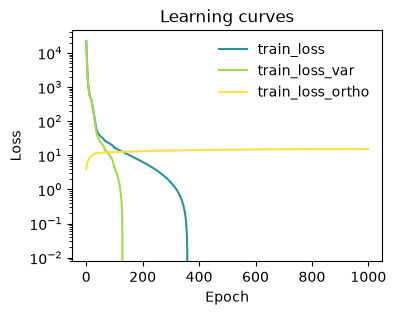

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
options = {
    "nn": {"activation": "tanh"},
    "optimizer": {"lr": 5e-4, "weight_decay": 1e-5},
}

# Keep model hyperparameters explicit so they can be reused consistently later.
layers = [10, 32, 32, 1]
eta = 0.05
alpha = 20

# Detach dataset tensors to ensure they are leaf variables for each new model (relevant for training multiple models in a loop)
# and keep them on the active device used for training.
dataset_iter = DictDataset(
    {
        "data": dataset["data"].detach().clone().to(device),
        "weights": dataset["weights"].detach().clone().to(device),
        "derivatives": dataset["derivatives"].detach().clone().to(device),
    }
)

model = IndicatorTraining(
    layers=layers,
    eta=eta,
    alpha=alpha,
    friction=friction.to(device),
    options=options,
).to(device)

datamodule = DictModule(dataset_iter, lengths=[0.8, 0.2])
metrics = MetricsCallback()
trainer = lightning.Trainer(
    callbacks=[metrics],
    max_epochs=1000,
    enable_checkpointing=False,
    logger=False,
    limit_val_batches=0,
    num_sanity_val_steps=0,
)

# fit model
trainer.fit(model, datamodule)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = plot_metrics(
    metrics.metrics,
    keys=["train_loss", "train_loss_var", "train_loss_ortho"],
    colors=["fessa1", "fessa3", "fessa4", "fessa5"],
    ax=ax,
    yscale="log",
)

# Ensure model and evaluation tensors are on the same device before post-training inference.
model_device = next(model.parameters()).device
dataset_eval = DictDataset(
    {
        "data": dataset_iter["data"].to(model_device),
        "weights": dataset_iter["weights"].to(model_device),
        "derivatives": dataset_iter["derivatives"].to(model_device),
    }
)

g, evals, evecs = model.compute_eigenfunctions(dataset_eval)
coeffs = evecs.cpu().detach().real

# Set up the production model with the trained weights and computed coefficients
trivial = IndicatorProduction(
    layers=layers,
    eta=eta,
    alpha=alpha,
    friction=friction.cpu(),
    coeffs=coeffs[:, 0],
).to("cpu").to(torch.float32)

# Copy NN weights from trained model
trivial.nn = copy.deepcopy(model.nn).to("cpu").to(torch.float32)

# Estimate the lambda parameter for biasing
bias = IndicatorBiasModel(model.to("cpu"), l=1, e=1e-7).to(torch.float32)
bias_values = bias(dataset_eval["data"].cpu().detach())
lambda_value = 40 / (bias_values.max() - bias_values.min())
print("lambda_value", lambda_value)

In [ ]:
def convert_model(model_name, n_input):
    loaded_model = torch.jit.load(model_name).to(torch.device('cpu')).to(torch.float32)
    fake_input = torch.rand(1,n_input,dtype=torch.float32).to(torch.device('cpu')).to(torch.float32)
    loaded_model(fake_input)
    frozen_model = torch.jit.trace(loaded_model, fake_input)
    torch.jit.save(frozen_model, model_name)

In [ ]:
# Export the model to TorchScript
trivial.preprocessing = LogHistogram(in_features=20, min=-380, max=-300, bins=10)
traced_model = trivial.to("cpu").to_torchscript(file_path=f'model_trivial.pt', method='trace')
convert_model(f'model_trivial.pt',20)